# EDA — Code Comment Classification (Python)

Notebook này phân tích dữ liệu `python.csv` cho bài toán **phân loại multi-label câu chú thích mã nguồn**.

Mục tiêu:

- kiểm tra schema, chất lượng và tính nhất quán của dữ liệu;
- chuyển dữ liệu từ dạng long one-vs-rest sang ma trận multi-label;
- khảo sát mất cân bằng nhãn, label cardinality/density và đồng xuất hiện nhãn;
- phân tích độ dài, nội dung văn bản và phân bố theo `class`;
- kiểm tra nguy cơ rò rỉ dữ liệu và đề xuất cách chia k-fold;
- đưa ra khuyến nghị cho baseline ML, RoBERTa và metric đánh giá.

> Lưu ý: mô tả đề bài nói 6.738 mẫu. Notebook sẽ đối chiếu con số đó với chính file được cung cấp thay vì mặc định hai nguồn giống nhau.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('python.csv')
assert DATA_PATH.exists(), f'Không tìm thấy file: {DATA_PATH}'
DATA_PATH

WindowsPath('python.csv')

## 1. Đọc dữ liệu và kiểm tra cấu trúc

Các cột kỳ vọng:

- `comment_sentence_id`: định danh câu;
- `class`: class/API chứa comment;
- `comment_sentence`: nội dung comment;
- `category`: tên nhãn đang được xét;
- `instance_type`: đích nhị phân (1 = câu thuộc `category`, 0 = không thuộc);
- `partition`: chỉ báo phân vùng đi kèm từng dòng long-format.

In [2]:
df = pd.read_csv(DATA_PATH)
required = {'comment_sentence_id', 'class', 'comment_sentence', 'partition', 'instance_type', 'category'}
missing_columns = required - set(df.columns)
assert not missing_columns, f'Thiếu cột: {missing_columns}'

print(f'Số dòng long-format : {len(df):,}')
print(f'Số câu/ID duy nhất   : {df.comment_sentence_id.nunique():,}')
print(f'Số class duy nhất    : {df["class"].nunique():,}')
print(f'Số category          : {df.category.nunique():,}')
display(df.head())
display(df.dtypes.to_frame('dtype').T)

Số dòng long-format : 12,775
Số câu/ID duy nhất   : 2,555
Số class duy nhất    : 330
Số category          : 5


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,Usage
1,2,AccessMixin,functionality.,1,0,Usage
2,5,AmbiguityError,more than one migration matches a name prefix.,0,0,Usage
3,7,AppConfigStub,stub of an appconfig.,1,0,Usage
4,8,AppConfigStub,only provides a label and a dict of models.,0,0,Usage


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
dtype,int64,object,object,int64,int64,object


In [3]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=False),
})
display(quality)

print('Dòng trùng hoàn toàn:', df.duplicated().sum())
print('Giá trị instance_type:', sorted(df.instance_type.unique().tolist()))
print('Giá trị partition:', sorted(df.partition.unique().tolist()))
assert set(df.instance_type.unique()).issubset({0, 1}), 'instance_type không còn là biến nhị phân'
assert set(df.partition.unique()).issubset({0, 1}), 'partition có giá trị ngoài 0/1'

,dtype,missing,missing_%,n_unique
comment_sentence_id,int64,0,0.0,2555
class,object,0,0.0,330
comment_sentence,object,0,0.0,2299
partition,int64,0,0.0,2
instance_type,int64,0,0.0,2
category,object,0,0.0,5


Dòng trùng hoàn toàn: 0
Giá trị instance_type: [0, 1]
Giá trị partition: [0, 1]


## 2. Xác minh cách mã hóa multi-label

Một mẫu hợp lệ ở dạng long one-vs-rest phải có đúng một dòng cho mỗi `category`, đồng thời text và class không đổi trong cùng ID. Sau đó ta pivot `instance_type` thành các cột nhãn 0/1.

In [4]:
id_check = df.groupby('comment_sentence_id').agg(
    rows=('category', 'size'),
    n_categories=('category', 'nunique'),
    n_texts=('comment_sentence', 'nunique'),
    n_classes=('class', 'nunique'),
    n_partitions=('partition', 'nunique'),
)
display(id_check.describe().round(2))

expected_categories = df.category.nunique()
invalid_ids = id_check.query(
    'rows != @expected_categories or n_categories != @expected_categories or n_texts != 1 or n_classes != 1'
)
print(f'ID vi phạm cấu trúc long-format: {len(invalid_ids):,}')
assert invalid_ids.empty, 'Cần xử lý các ID không nhất quán trước khi pivot'

example_id = df.comment_sentence_id.iloc[0]
display(df.query('comment_sentence_id == @example_id').sort_values('category'))

,rows,n_categories,n_texts,n_classes,n_partitions
count,2555.0,2555.0,2555.0,2555.0,2555.00
mean,5.0,5.0,1.0,1.0,1.48
std,0.0,0.0,0.0,0.0,0.50
min,5.0,5.0,1.0,1.0,1.00
25%,5.0,5.0,1.0,1.0,1.00
50%,5.0,5.0,1.0,1.0,1.00
75%,5.0,5.0,1.0,1.0,2.00
max,5.0,5.0,1.0,1.0,2.00


ID vi phạm cấu trúc long-format: 0


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
3517,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,DevelopmentNotes
5760,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,Expand
1756,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,Parameters
12322,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,1,Summary
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,Usage


In [5]:
meta = (
    df[['comment_sentence_id', 'class', 'comment_sentence']]
    .drop_duplicates('comment_sentence_id')
    .set_index('comment_sentence_id')
)
y = (
    df.pivot(index='comment_sentence_id', columns='category', values='instance_type')
    .astype('int8')
    .sort_index(axis=1)
)
wide = meta.join(y).reset_index()
label_cols = y.columns.tolist()

print('Kích thước dữ liệu wide:', wide.shape)
print('Các nhãn:', label_cols)
display(wide.head())

Kích thước dữ liệu wide: (2555, 8)
Các nhãn: ['DevelopmentNotes', 'Expand', 'Parameters', 'Summary', 'Usage']


,comment_sentence_id,class,comment_sentence,DevelopmentNotes,Expand,Parameters,Summary,Usage
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,0,1,0
1,2,AccessMixin,functionality.,0,0,0,1,0
2,5,AmbiguityError,more than one migration matches a name prefix.,0,0,0,1,0
3,7,AppConfigStub,stub of an appconfig.,0,0,0,1,0
4,8,AppConfigStub,only provides a label and a dict of models.,0,0,1,0,0


## 3. Phân bố nhãn và mức mất cân bằng

- **Prevalence**: tỷ lệ mẫu dương của từng nhãn.
- **Imbalance ratio**: số âm / số dương; càng lớn càng khó học nhãn thiểu số.
- Không nên đánh giá chỉ bằng accuracy vì phần lớn ô trong ma trận nhãn là 0.

,positive,negative,prevalence_%,neg/pos_ratio
category,,,,
Usage,800,1755,31.31,2.19
Parameters,794,1761,31.08,2.22
Expand,504,2051,19.73,4.07
Summary,454,2101,17.77,4.63
DevelopmentNotes,312,2243,12.21,7.19


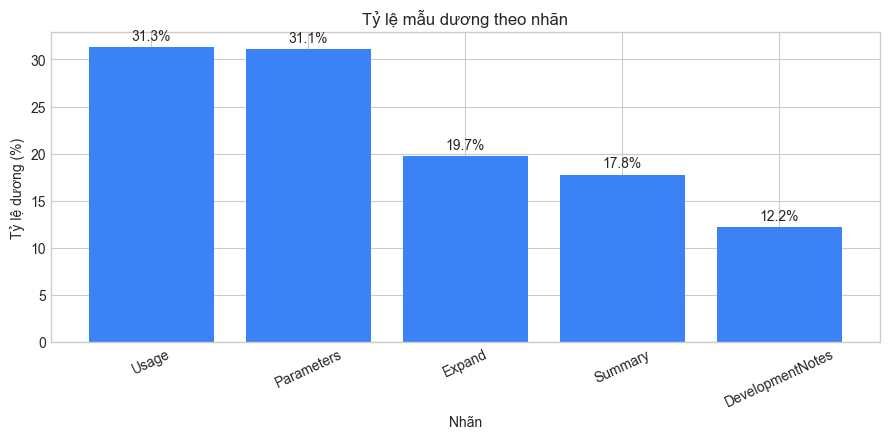

In [6]:
label_stats = pd.DataFrame({
    'positive': y.sum(),
    'negative': len(y) - y.sum(),
    'prevalence_%': (100 * y.mean()).round(2),
})
label_stats['neg/pos_ratio'] = (label_stats.negative / label_stats.positive).round(2)
label_stats = label_stats.sort_values('positive', ascending=False)
display(label_stats)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(label_stats.index, label_stats['prevalence_%'], color='#3b82f6')
ax.set(title='Tỷ lệ mẫu dương theo nhãn', xlabel='Nhãn', ylabel='Tỷ lệ dương (%)')
ax.tick_params(axis='x', rotation=25)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

Label cardinality (nhãn dương/mẫu): 1.121
Label density: 0.224
Mẫu không có nhãn dương: 0


,samples
1,2271
2,259
3,25


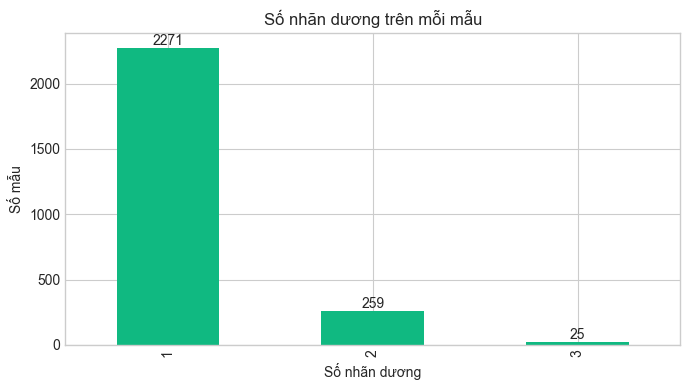

In [7]:
label_count = y.sum(axis=1)
cardinality = label_count.mean()
density = cardinality / y.shape[1]

print(f'Label cardinality (nhãn dương/mẫu): {cardinality:.3f}')
print(f'Label density: {density:.3f}')
print(f'Mẫu không có nhãn dương: {(label_count == 0).sum():,}')
display(label_count.value_counts().sort_index().rename('samples').to_frame())

ax = label_count.value_counts().sort_index().plot.bar(figsize=(7, 4), color='#10b981')
ax.set(title='Số nhãn dương trên mỗi mẫu', xlabel='Số nhãn dương', ylabel='Số mẫu')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 4. Đồng xuất hiện và quan hệ giữa các nhãn

Heatmap đầu tiên là số mẫu cùng dương. Jaccard chuẩn hóa theo kích thước hợp của hai tập mẫu, giúp so sánh các cặp nhãn công bằng hơn.

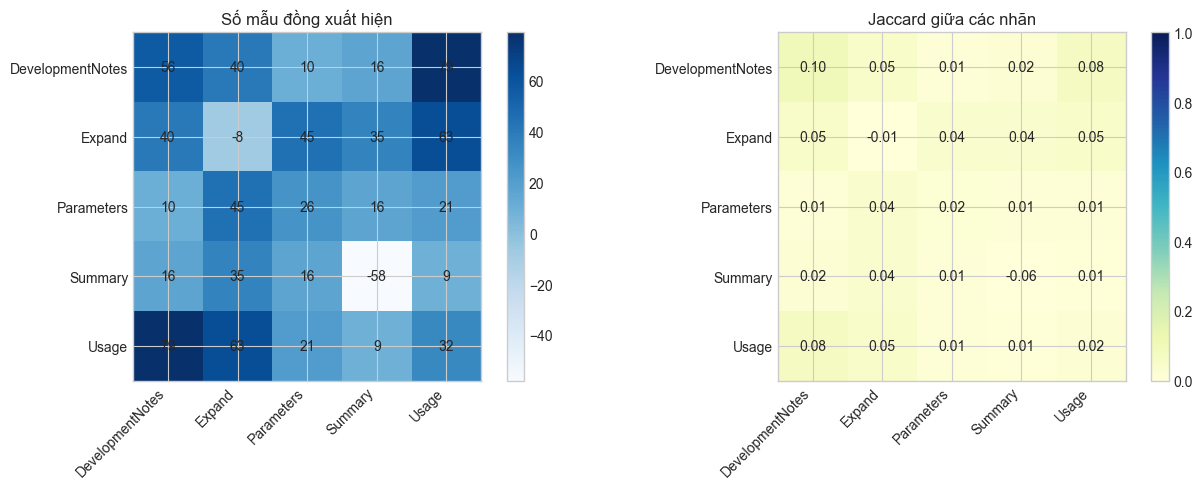

In [8]:
cooc = y.T.dot(y).astype(int)
union = np.zeros_like(cooc, dtype=float)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        union[i, j] = y.iloc[:, i].sum() + y.iloc[:, j].sum() - cooc.iloc[i, j]
jaccard = cooc.to_numpy() / np.where(union == 0, 1, union)
jaccard = pd.DataFrame(jaccard, index=label_cols, columns=label_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(cooc, cmap='Blues')
axes[0].set_xticks(range(len(label_cols)), label_cols, rotation=45, ha='right')
axes[0].set_yticks(range(len(label_cols)), label_cols)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        axes[0].text(j, i, f'{cooc.iloc[i, j]:d}', ha='center', va='center')
fig.colorbar(im0, ax=axes[0], fraction=.046)
axes[0].set_title('Số mẫu đồng xuất hiện')
im1 = axes[1].imshow(jaccard, cmap='YlGnBu', vmin=0, vmax=1)
axes[1].set_xticks(range(len(label_cols)), label_cols, rotation=45, ha='right')
axes[1].set_yticks(range(len(label_cols)), label_cols)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        axes[1].text(j, i, f'{jaccard.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im1, ax=axes[1], fraction=.046)
axes[1].set_title('Jaccard giữa các nhãn')
plt.tight_layout()
plt.show()

## 5. Phân tích văn bản

Độ dài theo từ và ký tự giúp lựa chọn `max_length` cho Transformer. Ta dùng phân vị thay vì lấy max tuyệt đối để tránh padding lãng phí do ngoại lệ.

,char_len,word_len
count,2555.00,2555.00
mean,38.70,6.73
std,22.51,4.04
min,1.00,0.00
50%,37.00,6.00
75%,59.00,10.00
90%,68.00,12.00
95%,72.30,13.00
99%,87.00,16.00
max,103.00,20.00


Có dấu hiệu code token: 39.2%
Bắt đầu bằng chữ thường: 96.2%


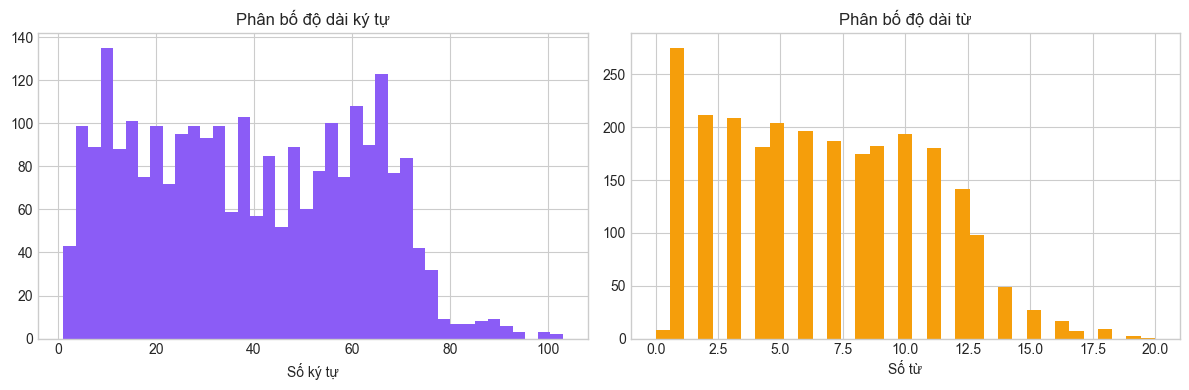

In [9]:
text_df = wide[['comment_sentence_id', 'class', 'comment_sentence']].copy()
text_df['char_len'] = text_df.comment_sentence.str.len()
text_df['word_len'] = text_df.comment_sentence.str.findall(r'\b\w+\b').str.len()
text_df['has_code_token'] = text_df.comment_sentence.str.contains(
    r'[_().=]|\b(?:class|def|return|None|True|False)\b', regex=True
)
text_df['starts_lowercase'] = text_df.comment_sentence.str.match(r'^[a-z]')

display(text_df[['char_len', 'word_len']].describe(percentiles=[.5, .75, .9, .95, .99]).round(2))
print(f'Có dấu hiệu code token: {text_df.has_code_token.mean():.1%}')
print(f'Bắt đầu bằng chữ thường: {text_df.starts_lowercase.mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(text_df.char_len, bins=40, color='#8b5cf6')
axes[0].set(title='Phân bố độ dài ký tự', xlabel='Số ký tự')
axes[1].hist(text_df.word_len, bins=35, color='#f59e0b')
axes[1].set(title='Phân bố độ dài từ', xlabel='Số từ')
plt.tight_layout()
plt.show()

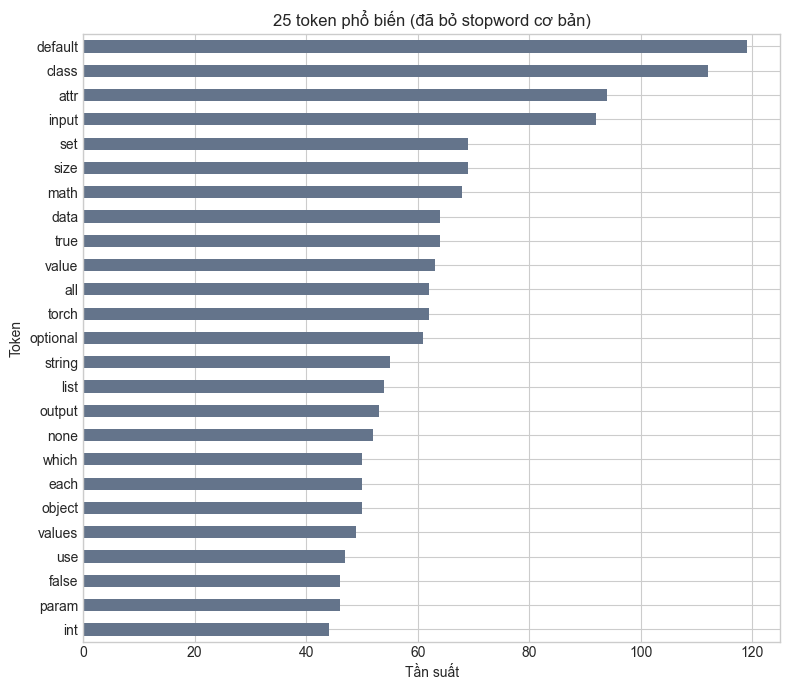

comment_sentence,default,class,attr,input,set,size,math,true,data,value,all,torch,optional,string,list,output,none,which,each,object,values,use,param,false,int
count,119,112,94,92,69,69,68,64,64,63,62,62,61,55,54,53,52,50,50,50,49,47,46,46,44


In [10]:
# Các token phổ biến sau tiền xử lý rất nhẹ; giữ nguyên tinh thần code comment.
stopwords = {
    'a','an','the','and','or','of','to','in','for','is','are','be','this','that',
    'with','as','on','by','from','it','if','not','will','can','used','using'
}
tokens = (
    text_df.comment_sentence.str.lower()
    .str.findall(r'[a-zA-Z_][a-zA-Z_0-9]+')
    .explode()
)
top_tokens = tokens[~tokens.isin(stopwords)].value_counts().head(25)

ax = top_tokens.sort_values().plot.barh(figsize=(8, 7), color='#64748b')
ax.set(title='25 token phổ biến (đã bỏ stopword cơ bản)', xlabel='Tần suất', ylabel='Token')
plt.tight_layout()
plt.show()
display(top_tokens.rename('count').to_frame().T)

## 6. Class, trùng lặp và nguy cơ leakage

Hai nguồn leakage quan trọng:

1. cùng `comment_sentence_id` nằm ở nhiều partition;
2. cùng nội dung text xuất hiện dưới nhiều ID khác nhau.

Vì vậy, split ngẫu nhiên theo **dòng long-format** là sai. Với đánh giá tổng quát hóa sang API/class mới, nên group theo `class`. Với đánh giá trên câu mới nhưng cùng miền class, ít nhất phải group theo text chuẩn hóa.

Số class: 330
Median số câu/class: 2
Class chỉ có 1 câu: 145


,n_sentences
class,
PlotAccessor,108
Unfold,94
Environment,92
Retry,83
BCEWithLogitsLoss,79
EmbeddingBag,70
ConfigDict,68
Conv3d,66
Audio,64


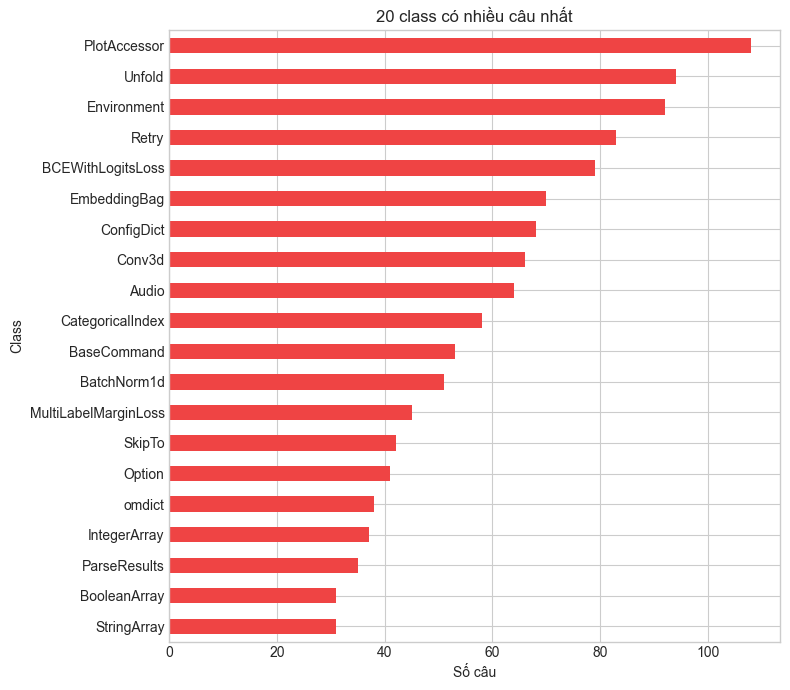

In [11]:
class_counts = text_df['class'].value_counts()
print(f'Số class: {class_counts.size:,}')
print(f'Median số câu/class: {class_counts.median():.0f}')
print(f'Class chỉ có 1 câu: {(class_counts == 1).sum():,}')
display(class_counts.head(15).rename('n_sentences').to_frame())

ax = class_counts.head(20).sort_values().plot.barh(figsize=(8, 7), color='#ef4444')
ax.set(title='20 class có nhiều câu nhất', xlabel='Số câu', ylabel='Class')
plt.tight_layout()
plt.show()

In [12]:
partition_by_id = df.groupby('comment_sentence_id').partition.nunique()
ids_crossing_partitions = int((partition_by_id > 1).sum())

normalized_text = (
    text_df.comment_sentence.str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
duplicate_text_rows = int(normalized_text.duplicated(keep=False).sum())
duplicate_text_groups = int(normalized_text[normalized_text.duplicated(keep=False)].nunique())

print(f'ID xuất hiện ở cả partition 0 và 1: {ids_crossing_partitions:,}/{len(text_df):,}')
print(f'Mẫu thuộc nhóm text trùng: {duplicate_text_rows:,}')
print(f'Số nhóm text trùng: {duplicate_text_groups:,}')

partition_table = pd.crosstab(df.partition, df.category)
display(partition_table)

if ids_crossing_partitions:
    display(Markdown(
        '**Cảnh báo:** `partition` thay đổi giữa các category của cùng một ID, nên không thể dùng trực tiếp '
        'như train/test split ở cấp mẫu multi-label. Hãy dựng dữ liệu wide trước rồi chia nhóm.'
    ))

ID xuất hiện ở cả partition 0 và 1: 1,231/2,555
Mẫu thuộc nhóm text trùng: 368
Số nhóm text trùng: 112


category,DevelopmentNotes,Expand,Parameters,Summary,Usage
partition,,,,,
0,2039,2039,2037,2039,2038
1,516,516,518,516,517


**Cảnh báo:** `partition` thay đổi giữa các category của cùng một ID, nên không thể dùng trực tiếp như train/test split ở cấp mẫu multi-label. Hãy dựng dữ liệu wide trước rồi chia nhóm.

## 7. Đề xuất k-fold và metric đánh giá

### Chia dữ liệu

- **Mục tiêu chính:** dùng iterative stratification cho multi-label (`MultilabelStratifiedKFold`, gói `iterative-stratification`) để giữ tỷ lệ từng nhãn.
- **Chống leakage:** tạo nhóm từ text đã chuẩn hóa; nếu muốn đo khả năng tổng quát hóa sang API chưa thấy, dùng `GroupKFold` theo `class`.
- Mọi bước vector hóa, resampling, feature selection và threshold tuning phải được fit **bên trong từng fold**.
- Với 5 fold, luôn báo cáo mean ± std và dùng cùng fold cho tất cả mô hình.

### Metric phù hợp

- `F1-micro`: chất lượng tổng thể, nhạy với nhãn phổ biến.
- `F1-macro`: mỗi nhãn có trọng số ngang nhau, quan trọng khi dữ liệu mất cân bằng.
- `F1-samples`: chất lượng tập nhãn trên từng mẫu.
- `Hamming loss`: tỷ lệ quyết định nhãn sai.
- `Jaccard-samples`: độ giống giữa tập nhãn dự đoán và thật.
- `Exact match / subset accuracy`: metric nghiêm ngặt; chỉ đúng khi toàn bộ vector nhãn đúng.
- `PR-AUC` theo nhãn và macro: phù hợp hơn ROC-AUC khi nhãn dương hiếm.

Threshold 0.5 không nhất thiết tối ưu. Nên tune threshold **riêng từng nhãn** trên validation fold, tuyệt đối không tune trên test fold.

In [13]:
# Mẫu code tạo fold. Ưu tiên iterative stratification nếu đã cài package.
X = wide[['comment_sentence_id', 'class', 'comment_sentence']].copy()
Y = wide[label_cols].to_numpy()

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    splitter = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    folds = list(splitter.split(X, Y))
    split_method = 'MultilabelStratifiedKFold'
except ImportError:
    from sklearn.model_selection import KFold
    splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    folds = list(splitter.split(X))
    split_method = 'KFold fallback (cài iterative-stratification để stratify multi-label)'

fold_rows = []
for fold, (train_idx, val_idx) in enumerate(folds, 1):
    row = {'fold': fold, 'train_n': len(train_idx), 'val_n': len(val_idx)}
    for j, label in enumerate(label_cols):
        row[f'{label}_val_%'] = round(100 * Y[val_idx, j].mean(), 2)
    fold_rows.append(row)

print('Phương pháp:', split_method)
display(pd.DataFrame(fold_rows))

Phương pháp: KFold fallback (cài iterative-stratification để stratify multi-label)


,fold,train_n,val_n,DevelopmentNotes_val_%,Expand_val_%,Parameters_val_%,Summary_val_%,Usage_val_%
0,1,2044,511,12.72,19.18,32.09,18.79,29.35
1,2,2044,511,14.29,20.74,30.14,18.20,31.51
2,3,2044,511,11.55,20.16,30.33,17.22,31.12
3,4,2044,511,10.18,18.98,31.31,17.61,32.49
4,5,2044,511,12.33,19.57,31.51,17.03,32.09


## 8. Hướng mô hình hóa và baseline so sánh

| Nhóm | Mô hình | Ghi chú |
|---|---|---|
| Dummy | dự đoán theo prevalence / nhãn phổ biến | mốc sàn bắt buộc |
| ML mạnh, rẻ | word + char TF-IDF → One-vs-Rest Logistic Regression | baseline nên chạy đầu tiên |
| Khai thác phụ thuộc nhãn | Classifier Chains / calibrated linear model | so với binary relevance |
| Transformer | RoBERTa + 5 sigmoid outputs + BCEWithLogitsLoss | baseline chuyên biệt theo đề bài |

Khuyến nghị cho RoBERTa:

- Không dùng softmax; đầu ra là 5 logits độc lập và loss là binary cross-entropy.
- Cân nhắc `pos_weight` theo nhãn hoặc focal loss, nhưng phải so sánh công bằng với BCE thường.
- Chọn `max_length` dựa trên phân vị độ dài token (file này có comment ngắn, không nên mặc định 512).
- Early stopping theo macro-F1 hoặc macro PR-AUC trên validation.
- Báo cáo metric tổng hợp, metric từng nhãn, thời gian train/inference và độ lệch chuẩn qua 5 fold.

Để so sánh đáng tin cậy, cùng một seed/fold, cùng quy tắc threshold, và không dùng test fold để chọn hyperparameter.

## 9. Kết luận tự động từ file hiện tại

In [14]:
rarest = label_stats['prevalence_%'].idxmin()
most_common = label_stats['prevalence_%'].idxmax()
p95_words = text_df.word_len.quantile(.95)

summary = f'''### Tóm tắt

- File có **{len(df):,} dòng long-format**, tương ứng **{len(wide):,} mẫu câu duy nhất**, **{len(label_cols)} nhãn** và **{text_df['class'].nunique():,} class**.
- Con số mẫu thực trong file (**{len(wide):,}**) không khớp mô tả 6.738 mẫu; cần xác nhận phiên bản/subset dữ liệu trước khi báo cáo cuối.
- Mỗi mẫu có trung bình **{cardinality:.2f} nhãn dương**; không có mẫu rỗng nhãn: **{int((label_count == 0).sum()):,}**.
- Nhãn phổ biến nhất là **{most_common}** ({label_stats.loc[most_common, 'prevalence_%']:.2f}%), hiếm nhất là **{rarest}** ({label_stats.loc[rarest, 'prevalence_%']:.2f}%).
- 95% câu có không quá **{p95_words:.0f} từ**, gợi ý sequence length ngắn là đủ cho phần lớn mẫu.
- Có **{ids_crossing_partitions:,} ID** xuất hiện ở cả hai partition: không dùng cột `partition` trực tiếp làm train/test split cho bài toán wide multi-label.
- Có **{duplicate_text_rows:,} mẫu** nằm trong các nhóm text trùng; split cần group-aware để tránh leakage.
'''
display(Markdown(summary))

### Tóm tắt

- File có **12,775 dòng long-format**, tương ứng **2,555 mẫu câu duy nhất**, **5 nhãn** và **330 class**.
- Con số mẫu thực trong file (**2,555**) không khớp mô tả 6.738 mẫu; cần xác nhận phiên bản/subset dữ liệu trước khi báo cáo cuối.
- Mỗi mẫu có trung bình **1.12 nhãn dương**; không có mẫu rỗng nhãn: **0**.
- Nhãn phổ biến nhất là **Usage** (31.31%), hiếm nhất là **DevelopmentNotes** (12.21%).
- 95% câu có không quá **13 từ**, gợi ý sequence length ngắn là đủ cho phần lớn mẫu.
- Có **1,231 ID** xuất hiện ở cả hai partition: không dùng cột `partition` trực tiếp làm train/test split cho bài toán wide multi-label.
- Có **368 mẫu** nằm trong các nhóm text trùng; split cần group-aware để tránh leakage.
